# **A/B Test: Revenue-Focused Analysis**

<br></br>

This project analyzes the impact of a product experiment using revenue‑focused A/B testing. To evaluate whether the treatment meaningfully improved user monetization, I examined three core metrics: Average Revenue Per User (ARPU), Conversion Rate (CR), and Average Revenue Per Paying User (ARPPU). Together, these metrics provide a clear view of both user behavior and revenue quality, allowing for a more reliable assessment of the experiment's business impact.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, mannwhitneyu



---



### **Data Preprocessing**

In [2]:
# Load dataset on Google Drive
file_id = '1XOeYZj-XOrC2zzbEEsqVX1oxozU9-sxM'
url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url)

# Show first 5 rows
print(df.head())

   USER_ID VARIANT_NAME  REVENUE
0      737      variant      0.0
1     2423      control      0.0
2     9411      control      0.0
3     7311      control      0.0
4     6174      variant      0.0


In [3]:
# check missing values
df.isna().sum()

,0
USER_ID,0
VARIANT_NAME,0
REVENUE,0


In [8]:
# Check duplicates
df.duplicated().sum()

np.int64(2067)

In [12]:
# Drop duplicates
df = df.drop_duplicate

In [13]:
df['USER_ID'].nunique(), len(df)

(6324, 7933)

So 1,609 users appear more than once.

In [16]:
# Collapse dataset to user level only
user_df = df.groupby('USER_ID').agg({
    'VARIANT_NAME': 'first',
    'REVENUE': 'sum'
}).reset_index()


In [17]:
# is user id unique this time?
user_df['USER_ID'].nunique(), len(user_df)

(6324, 6324)

Now user id is unique

In [18]:
user_df['VARIANT_NAME'].unique()

array(['control', 'variant'], dtype=object)

Variant element in `VARIANT_NAME` is too generic. Usually, in experimentation, the word "treatment" is considered standard. Let's proceed to rename it.

In [19]:
# Change 'variant' to 'treatment'
user_df['VARIANT_NAME'] = user_df['VARIANT_NAME'].str.replace('variant', 'treatment')

In [20]:
# Check 'VARIANT_NAME' element
user_df['VARIANT_NAME'].unique()

array(['control', 'treatment'], dtype=object)

# What the value of 0 means in the dataset?




In most e‑commerce and subscription environments, the majority of users never complete a purchase. When a user visits the site or app, and does not buy anything, their revenue contribution is recorded as 0.

This appears counterintuitive, but this is completely normal and creates what analysts call a *zero‑inflated distribution*, which is a dataset where most observations are zero and only a small fraction reflect actual spending.

Because of this structure, statistical testing require caution due to the highly skewed distribution of generated revenues, and the average revenue per user (ARPU) tend to be small. In this notebook, the Convertion Rate will be of extreme important for further analysis.

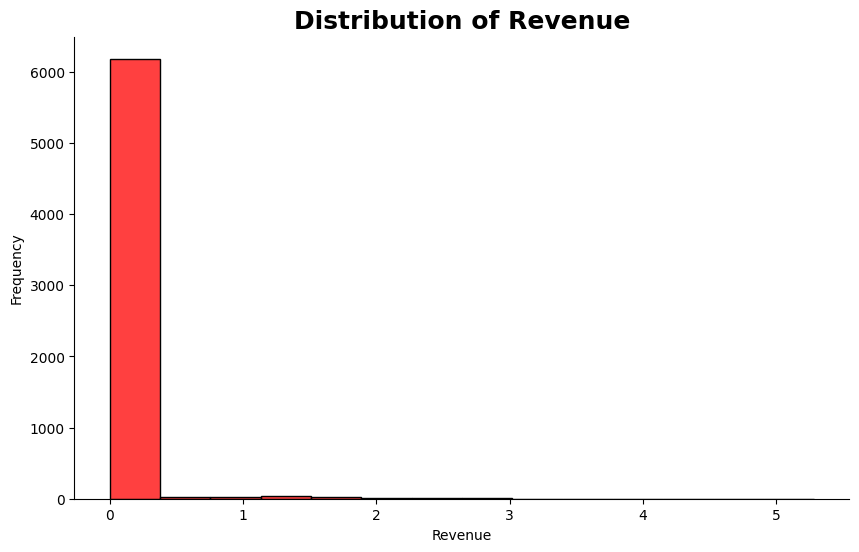

In [21]:
# Plot Revenue zero-inflated distribution
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(user_df['REVENUE']), color='r')
plt.title('Distribution of Revenue', fontweight= 'bold', fontsize= 18)
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

### Comment:
Even when `REVENUE` is log-transformed, the distribution is still highly asymmetric and skewed. Also, it's difficult to observe the values for the non-zero values. Here a cleaner distribution of the non-zero values of `REVENUE` column.

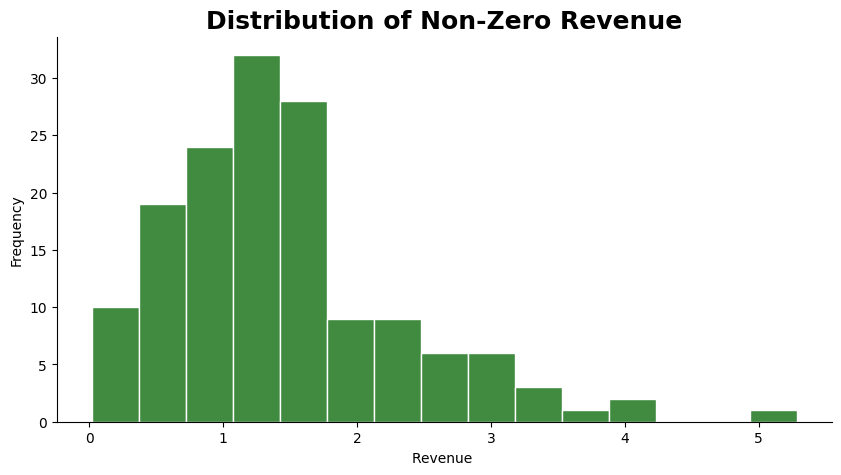

In [22]:
#  Plot non-zero values
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(user_df[user_df['REVENUE'] > 0]['REVENUE']), color='darkgreen', edgecolor='white')
plt.title('Distribution of Non‑Zero Revenue', fontweight='bold', fontsize=18)
plt.xlabel('Revenue ')
plt.ylabel('Frequency')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()


<br></br>

Since the sample is skewed, calculating the median revenue can handle the outliers in theory.

In [23]:
# Grouping metric with median
df_grouped1 = user_df.groupby('VARIANT_NAME')['REVENUE'].median().reset_index()
df_grouped1

,VARIANT_NAME,REVENUE
0,control,0.0
1,treatment,0.0


This happens because most users did not buy anything, and because the median is the middle value, if 50% of users have zero revenue, then it's no surprise the median is zero for both variants. Switchinh to other metrics such as ARPU will provide more insights on users behavior.



---



## **Revenue Impact Across Key Metrics**


1. The Average Revenue per User (**ARPU**) will analayze the overall revenue impact
2. The Conversion Rate (**CR**) will conclude whether treatment increases likelihood of buying
3. The Average Revenue per Paying User (**ARPPU**) will analyze treatment changes spending among buyers

In [24]:
# Conversion: revenue > 0
user_df['IS_PAYING'] = (user_df['REVENUE'] > 0).astype(int)

# Compute key metrics
metrics = user_df.groupby('VARIANT_NAME').agg(
    Conversion_Rate = ('IS_PAYING', 'mean'),
    ARPU            = ('REVENUE', 'mean'),
    ARPPU           = ('REVENUE', lambda x: x[x > 0].mean()),
    Paying_Users    = ('IS_PAYING', 'sum'),
    Total_Users     = ('IS_PAYING', 'count')
).reset_index()

metrics


,VARIANT_NAME,Conversion_Rate,ARPU,ARPPU,Paying_Users,Total_Users
0,control,0.026820,0.207340,7.730833,84,3132
1,treatment,0.020677,0.108108,5.228485,66,3192


/tmp/ipython-input-4039989024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics, x='VARIANT_NAME', y='ARPU', palette='Dark2')


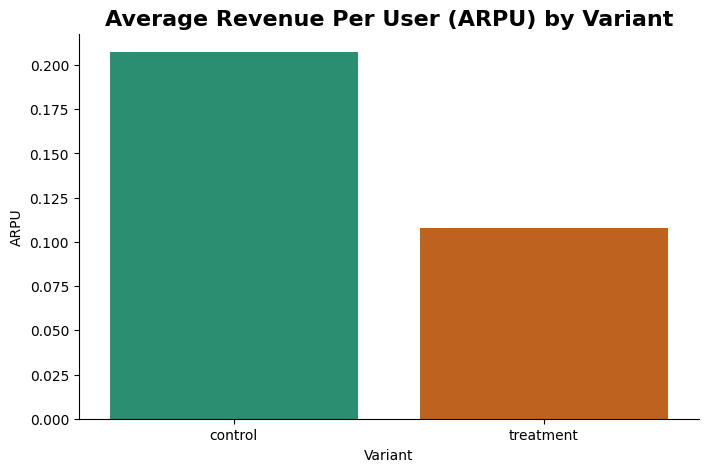

In [25]:
# Plot average revenue per user (arpu)
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics, x='VARIANT_NAME', y='ARPU', palette='Dark2')
plt.title('Average Revenue Per User (ARPU) by Variant', fontsize=16, fontweight='bold')
plt.xlabel('Variant')
plt.ylabel('ARPU')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()


This tells us that a small number of users did generate revenue and control group has slightly higher ARPU than treatment in this sample, even though user spending pulls the mean upward with zero-inflated data.

/tmp/ipython-input-1603202531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics, x='VARIANT_NAME', y='Conversion_Rate', palette='seismic')


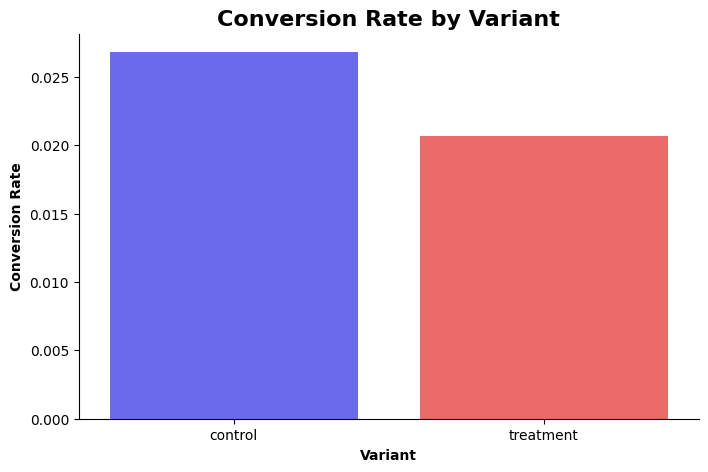

In [26]:
# Plot conversion rate
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics, x='VARIANT_NAME', y='Conversion_Rate', palette='seismic')
plt.title('Conversion Rate by Variant', fontsize=16, fontweight='bold')
plt.xlabel('Variant', fontweight = 'bold')
plt.ylabel('Conversion Rate', fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()


/tmp/ipython-input-1976719528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics, x='VARIANT_NAME', y='ARPPU', palette='coolwarm')


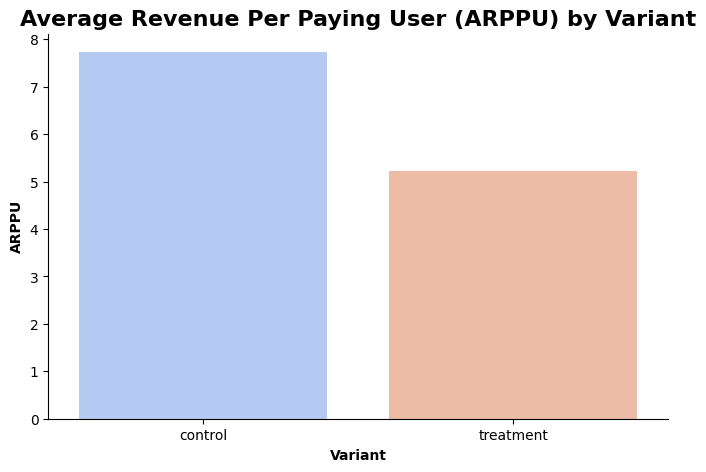

In [27]:
# Plot average revenue per paying user (ARPPU)
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics, x='VARIANT_NAME', y='ARPPU', palette='coolwarm')

plt.title('Average Revenue Per Paying User (ARPPU) by Variant', fontsize=16, fontweight='bold')
plt.xlabel('Variant', fontweight = 'bold')
plt.ylabel('ARPPU', fontweight= 'bold')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()


<br></br>

## [Statistical Method Used: BOOTSTRAP](https://statisticsbyjim.com/hypothesis-testing/bootstrapping/)

#### ARPU Bootstrap Testing

Hypothesis:

H0: ARPU_treatment <= ARPU_control

H1: ARPU_treatment > ARPU_control



In [28]:
#Split data Into control and treatment
control = user_df[user_df['VARIANT_NAME'] == 'control']['REVENUE'].values
treatment = user_df[user_df['VARIANT_NAME'] == 'treatment']['REVENUE'].values

In [29]:
obs_diff = treatment.mean() - control.mean()
obs_diff

np.float64(-0.0992325881754194)

In [30]:
# Bootstrap Loop
n_boot = 10000
boot_diffs = []

# Bootstrap Resampling
for i in range(n_boot):

    # resample control with replacement
    boot_control = np.random.choice(control, size=len(control), replace=True)

    # resample treatment with replacement
    boot_treatment = np.random.choice(treatment, size=len(treatment), replace=True)

    # compute ARPU difference for this bootstrap sample
    diff = boot_treatment.mean() - boot_control.mean()

    # store it
    boot_diffs.append(diff)


In [31]:
# Compute the 95% Confidence
lower = np.percentile(boot_diffs, 2.5)
upper = np.percentile(boot_diffs, 97.5)
(lower, upper)

(np.float64(-0.26528576169830703), np.float64(0.021444219384668572))

The interval includes zero. **The result is not statistically significant.**

In [32]:
# One-sided test where treatment > control
p_value = np.mean(np.array(boot_diffs) >= obs_diff)
p_value


np.float64(0.5413)

The one‑sided p‑value for the hypothesis that the treatment increases ARPU is high, indicating that the observed difference is associated with random variations.

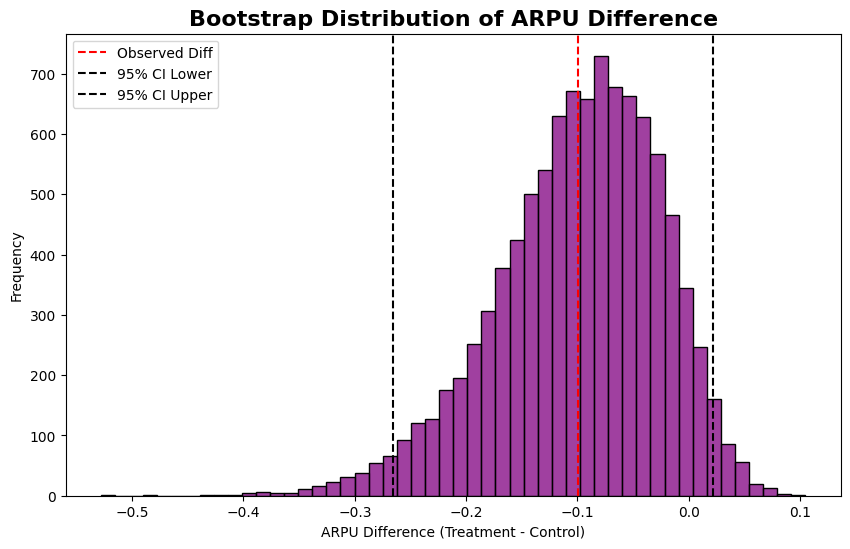

In [33]:
# Plot ARPU difference
plt.figure(figsize=(10,6))
sns.histplot(boot_diffs, bins=50, color='purple')

plt.axvline(obs_diff, color='red', linestyle='--', label='Observed Diff')
plt.axvline(lower, color='black', linestyle='--', label='95% CI Lower')
plt.axvline(upper, color='black', linestyle='--', label='95% CI Upper')

plt.title('Bootstrap Distribution of ARPU Difference', fontsize=16, fontweight='bold')
plt.xlabel('ARPU Difference (Treatment - Control)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


<br></br>

### Conversion Rate (CR) Bootstrap Testing

Hypothesis:

H0: CR_treatment <= CR_control

H1: CR_treatment > CR_control



In [34]:
control_conv = user_df[user_df['VARIANT_NAME'] == 'control']['IS_PAYING'].values
treatment_conv = user_df[user_df['VARIANT_NAME'] == 'treatment']['IS_PAYING'].values


In [35]:
obs_diff_cr = treatment_conv.mean() - control_conv.mean()
obs_diff_cr


np.float64(-0.006143231642324203)

In [36]:
n_boot = 10000
boot_diffs_cr = []

for i in range(n_boot):
    boot_control = np.random.choice(control_conv, size=len(control_conv), replace=True)
    boot_treatment = np.random.choice(treatment_conv, size=len(treatment_conv), replace=True)

    diff = boot_treatment.mean() - boot_control.mean()
    boot_diffs_cr.append(diff)


In [37]:
lower_cr = np.percentile(boot_diffs_cr, 2.5)
upper_cr = np.percentile(boot_diffs_cr, 97.5)
(lower_cr, upper_cr)


(np.float64(-0.013728046169062504), np.float64(0.0014297297362179352))

The interval includes zero. **The result is not statistically significant.**

In [38]:
p_value_cr = np.mean(np.array(boot_diffs_cr) >= obs_diff_cr)
p_value_cr

np.float64(0.5041)

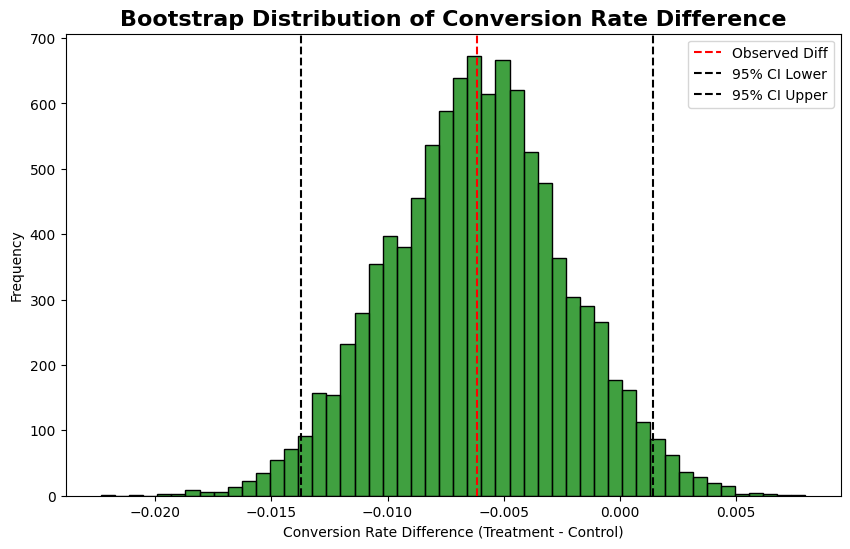

In [39]:
# plot CR difference
plt.figure(figsize=(10,6))
sns.histplot(boot_diffs_cr, bins=50, color='green')

plt.axvline(obs_diff_cr, color='red', linestyle='--', label='Observed Diff')
plt.axvline(lower_cr, color='black', linestyle='--', label='95% CI Lower')
plt.axvline(upper_cr, color='black', linestyle='--', label='95% CI Upper')

plt.title('Bootstrap Distribution of Conversion Rate Difference', fontsize=16, fontweight='bold')
plt.xlabel('Conversion Rate Difference (Treatment - Control)')
plt.ylabel('Frequency')
plt.legend()

plt.show()


<br></br>

### ARPPU Boostrap Testing

This time, we only use users with revenue > 0, because it's the average revenue per paying user.



Hypothesis:

H0: ARPPU_treatment <= ARPPU_control

H1: ARPPU_treatment > ARPPU_control





In [47]:
control_pay = user_df[(user_df['VARIANT_NAME'] == 'control') & (user_df['REVENUE'] > 0)]['REVENUE'].values
treatment_pay = user_df[(user_df['VARIANT_NAME'] == 'treatment') & (user_df['REVENUE'] > 0)]['REVENUE'].values

In [48]:
obs_diff_arppu = treatment_pay.mean() - control_pay.mean()
obs_diff_arppu

np.float64(-2.5023484848484836)

In [49]:
n_boot = 10000
boot_diffs_arppu = []

for i in range(n_boot):
    boot_control = np.random.choice(control_pay, size=len(control_pay), replace=True)
    boot_treatment = np.random.choice(treatment_pay, size=len(treatment_pay), replace=True)

    diff = boot_treatment.mean() - boot_control.mean()
    boot_diffs_arppu.append(diff)


In [50]:
lower_arppu = np.percentile(boot_diffs_arppu, 2.5)
upper_arppu = np.percentile(boot_diffs_arppu, 97.5)
(lower_arppu, upper_arppu)

(np.float64(-8.300921807359307), np.float64(2.030196428571427))

The interval includes zero. **The result is not statistically significant.**

In [51]:
p_value_arppu = np.mean(np.array(boot_diffs_arppu) >= obs_diff_arppu)
p_value_arppu

np.float64(0.5461)

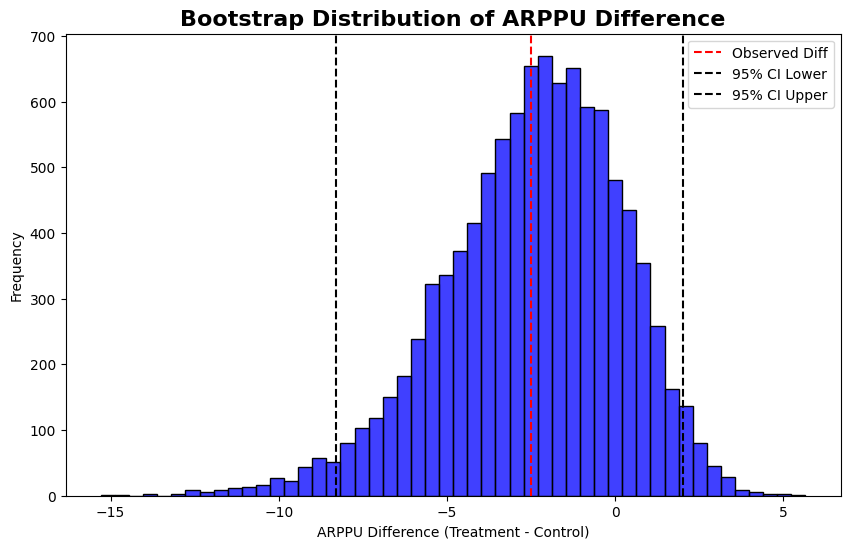

In [52]:
# plot ARPPU group differencce
plt.figure(figsize=(10,6))
sns.histplot(boot_diffs_arppu, bins=50, color='blue')

plt.axvline(obs_diff_arppu, color='red', linestyle='--', label='Observed Diff')
plt.axvline(lower_arppu, color='black', linestyle='--', label='95% CI Lower')
plt.axvline(upper_arppu, color='black', linestyle='--', label='95% CI Upper')

plt.title('Bootstrap Distribution of ARPPU Difference', fontsize=16, fontweight='bold')
plt.xlabel('ARPPU Difference (Treatment - Control)')
plt.ylabel('Frequency')
plt.legend()

plt.show()




---



# **Conclusion**
Across all three revenue metrics(CR, ARPU, and ARPPU), the treatment shows no statistically significant improvement over the control group. The bootstrap confidence intervals for each metric include zero, and the one‑sided tests provide no evidence that the treatment outperforms the control.

There is no reliable indication that the treatment increases revenue or improves user purchasing behavior, and, therefore, **deploying the treatment to all users is not recommended.**